<a href="https://colab.research.google.com/github/ganesh838/Amazon-clone/blob/main/App_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
raw_data=pd.read_csv("/content/googleplaystore.csv",on_bad_lines="skip")

In [ ]:
raw_data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df=raw_data.copy()

In [ ]:
print(print("\033[1;1000m  Missing values count\033[0m"))
print(raw_data.isnull().sum())

  Missing values count
None
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [ ]:
df=raw_data.copy()



In [ ]:
# 1. What is the average rating of apps in the dataset?

df['Installs'] = df['Installs'].astype(str).str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [ ]:
# 2. How many unique categories of apps are there?

df["Price"] = df['Price'].str.replace("$", "", regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors="coerce")

In [ ]:
# 3. Clean 'Reviews': Convert string to numeric integer
df["Reviews"]=pd.to_numeric(df['Reviews'],errors="coerce")

In [ ]:
# 4. Clean 'Size': Convert 'M' and 'k' to megabytes (floats)
def convert_size(Size):
  if Size.endswith('M'):
    return float(Size[:-1])
  elif Size.endswith("K"):
    return float(Size[:-1])/ 1024
  else:
    return None
df["Size"] = df["Size"].astype(str).apply(convert_size)

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# Clean 'Last update': Convert string to datetime integer
df["Last Updated"] = pd.to_datetime(df['Last Updated'],errors="coerce")

In [ ]:
print("duplicate rows count:",raw_data.duplicated().sum())

duplicate rows count: 483


In [ ]:
# Drop rows where crucial fields failed to parse (e.g. malformed rows)
df.dropna(subset=["Installs","Price","Reviews"],inplace=True)


In [ ]:
# Impute missing 'Rating' values with the median rating
df['Rating'].fillna(df['Rating'].median(),inplace=True)

/tmp/ipykernel_1129/634815028.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].median(),inplace=True)


In [ ]:
df.dropna(subset=['App'],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          10840 non-null  float64       
 3   Reviews         10840 non-null  float64       
 4   Size            8829 non-null   float64       
 5   Installs        10840 non-null  float64       
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 1.2+ MB


In [ ]:
# df.duplicated().sum()
# df.isnull().sum()

*Basic-Level Questions:*


In [ ]:
# 1. What is the average rating of apps in the dataset?
df['Rating'].mean().round(2)

np.float64(4.21)

In [ ]:
# 2. How many unique categories of apps are there?
df['Category'].nunique()

33

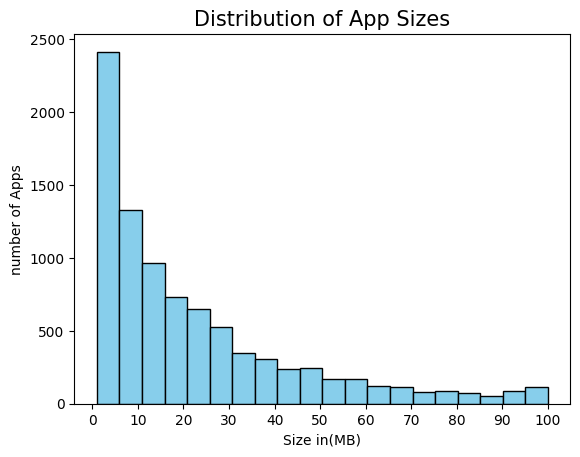

In [ ]:
# 3. What is the distribution of app sizes?
plt.hist(df['Size'].dropna(),bins=20,color='skyblue',edgecolor='black')
plt.xlabel('Size in(MB)')
plt.ylabel('number of Apps')
plt.title('Distribution of App Sizes',fontsize=15)
plt.xticks(range(0,101,10))
plt.show()

In [ ]:
# 4. How many free vs paid apps are there?
df['Type'].value_counts()

,count
Type,
Free,10039
Paid,800


In [ ]:
# 5. What is the most common content rating for apps?
df['Content Rating'].value_counts()

,count
Content Rating,
Everyone,8714
Teen,1208
Mature 17+,499
Everyone 10+,414
Adults only 18+,3
Unrated,2


In [ ]:
# 6. What are the top 5 most installed apps?
df.groupby('App')['Installs'].sum().sort_values(ascending=False).head(5)

,Installs
App,
Subway Surfers,6.000000e+09
Google Drive,4.000000e+09
Google Photos,4.000000e+09
Hangouts,4.000000e+09
Google News,4.000000e+09


In [ ]:
# 7. How many apps have a rating of 4.0 and above?
rating_4_plus_count = (df['Rating'] >= 4.0).sum()
print("Number of apps with rating >= 4.0:", rating_4_plus_count)

Number of apps with rating >= 4.0: 8842


In [ ]:
# 8. What is the average number of reviews for free vs paid apps?
df['Reviews'] = pd.to_numeric(raw_data['Reviews'], errors='coerce').inplace=True
df.groupby("Type")["Reviews"].mean().round(2)

,Reviews
Type,
Free,1.0
Paid,1.0


In [ ]:
# 9. What is the average app size for each category?
df.groupby("Category")["Size"].mean()

,Size
Category,
ART_AND_DESIGN,12.370968
AUTO_AND_VEHICLES,20.571233
BEAUTY,13.795745
BOOKS_AND_REFERENCE,13.846032
BUSINESS,14.868895
COMICS,14.014286
COMMUNICATION,13.163136
DATING,16.704265
EDUCATION,21.162385


In [ ]:
# 10. How many apps were last updated in 2018?
df['Last Updated'] = pd.to_datetime(df['Last Updated'])
df['last_updated_year'] = df['Last Updated'].dt.year
last_updated_2018_count = (df['last_updated_year'] == 2018).sum()
print(last_updated_2018_count)

7349


# **Medium-Level Questions:**

In [ ]:
# 1. What is the correlation between the number of installs and the app rating?
correlation = df['Installs'].corr(df['Rating'])
print("Correlation between Installs and Rating:", correlation)

Correlation between Installs and Rating: 0.045495833516275355


In [ ]:
# 2. Which app categories have the highest average rating?
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

,Rating
Category,
EVENTS,4.395313
EDUCATION,4.388462
ART_AND_DESIGN,4.355385
BOOKS_AND_REFERENCE,4.335498
PERSONALIZATION,4.328827
PARENTING,4.300000
GAME,4.286888
BEAUTY,4.283019
HEALTH_AND_FITNESS,4.280059


In [ ]:
# 3. How does the price of an app affect its average rating?
df.groupby('Price')['Rating'].mean().sort_values(ascending=False)

,Rating
Price,
3.04,5.0
1.75,5.0
2.50,4.8
2.59,4.7
15.99,4.7
...,...
2.56,3.4
15.46,3.4
4.60,3.4


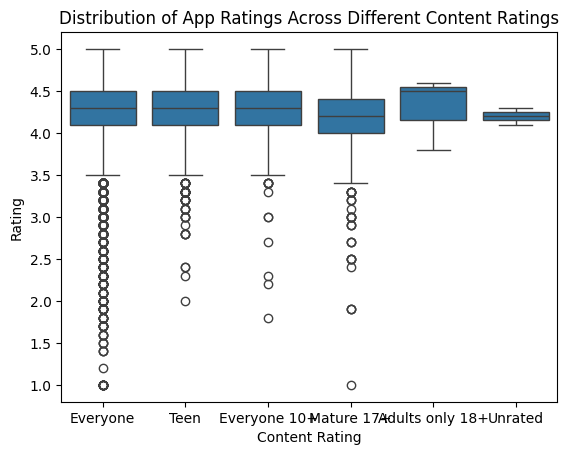

In [ ]:
# 4. What is the distribution of app ratings across different content ratings?
sns.boxplot(x='Content Rating',y='Rating',data=df)
plt.xlabel('Content Rating')
plt.ylabel('Rating')
plt.title('Distribution of App Ratings Across Different Content Ratings')
plt.show()


In [ ]:
# 5. Which genres have the most apps with over 1 million installs?
high_install_apps = df[df['Installs'] > 1000000]
genre_counts = high_install_apps.groupby("Genres")['App'].count().sort_values(ascending=False)
print(genre_counts)

Genres
Action                       190
Tools                        187
Photography                  172
Communication                167
Productivity                 138
                            ... 
Parenting                      1
Role Playing;Brain Games       1
Parenting;Music & Video        1
Sports;Action & Adventure      1
Tools;Education                1
Name: App, Length: 88, dtype: int64


In [ ]:
# 6. How frequently do apps get updated? Calculate the average time between updates.
df['Last Updated'] = pd.to_datetime(df['Last Updated'],errors='coerce')
df = df.sort_values(by=['App', 'Last Updated'])
time_between_updates = df.groupby("App")["Last Updated"].diff().dt.days
avg_time_between_updates = time_between_updates.mean()
print("Average time between updates:",avg_time_between_updates)

Average time between updates: 4.657070279424217


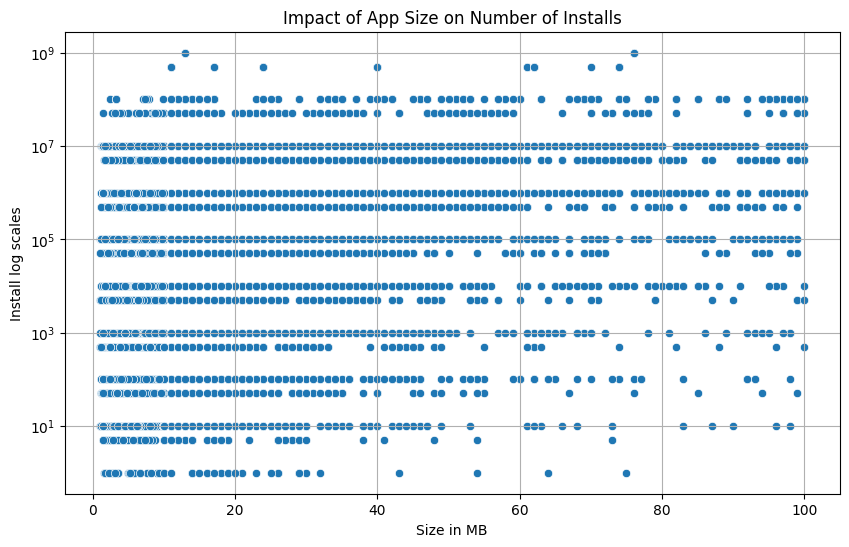

In [ ]:
# 7. What is the impact of app size on the number of installs?
plt.figure(figsize=(10,6))
sns.scatterplot(x='Size',y='Installs',data=df)
plt.yscale('log')
plt.xlabel('Size in MB')
plt.ylabel('Install log scales')
plt.title('Impact of App Size on Number of Installs')
plt.grid(True)


In [ ]:
# 8. Which apps have the highest number of reviews, and what are their ratings?
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
top_reviews = df.nlargest(10, 'Reviews')
print(top_reviews[['App', 'Reviews', 'Rating']])

                                        App  Reviews  Rating
8884   "i DT" Fútbol. Todos Somos Técnicos.     True     4.3
8532          +Download 4 Instagram Twitter     True     4.5
324              - Free Comics - Comic Apps     True     3.5
4541                                     .R     True     4.5
4636                                 /u/app     True     4.7
5940                                 058.ba     True     4.4
10252                        1. FC Köln App     True     4.6
1393                  10 Best Foods for You     True     4.0
1407                  10 Best Foods for You     True     4.0
8483          10 Minutes a Day Times Tables     True     4.1


In [ ]:
# 9. How does the content rating distribution differ between free and paid apps?

content_percentages = (
    pd.crosstab(df["Type"], df["Content Rating"], normalize="index") * 100
)
print("\n--- Percentage Breakdown (%) ---")
print(content_percentages.round(2))


--- Percentage Breakdown (%) ---
Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+   Teen  \
Type                                                                         
Free                       0.03     79.88          3.79        4.77  11.52   
Paid                       0.00     86.88          4.12        2.50   6.50   

Content Rating  Unrated  
Type                     
Free               0.02  
Paid               0.00  


In [ ]:
# 10. What are the top 5 categories with the most installs?
top_categories = df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(5)
print(top_categories)

Category
GAME             3.508602e+10
COMMUNICATION    3.264728e+10
PRODUCTIVITY     1.417609e+10
SOCIAL           1.406987e+10
TOOLS            1.145277e+10
Name: Installs, dtype: float64


## **Advanced-Level Questions:**


In [ ]:

# 1. What are the top 10 apps with the highest ratings, and how do their number of reviews and installs compare?
top_apps = df.nlargest(10, 'Rating')
top_apps = top_apps.sort_values(by='Rating', ascending=False)
print(top_apps[['App', 'Rating', 'Reviews', 'Installs','Category']])


                                                    App  Rating  Reviews  \
7466                                             211:CK     5.0     True   
8018  30WPM Amateur ham radio Koch CW Morse code tra...     5.0     True   
2522                             420 BZ Budeze Delivery     5.0     True   
7035                             420 BZ Budeze Delivery     5.0     True   
5828                                     A-Y Collection     5.0     True   
8287                                AC DC Power Monitor     5.0     True   
3957                                       ADS-B Driver     5.0     True   
5196   AI Today : Artificial Intelligence News & AI 101     5.0     True   
5263                                  AJ Blue Icon Pack     5.0     True   
5230                                             AJ Cam     5.0     True   

      Installs            Category  
7466      10.0                GAME  
8018      10.0              FAMILY  
2522     100.0             MEDICAL  
7035     100.0 

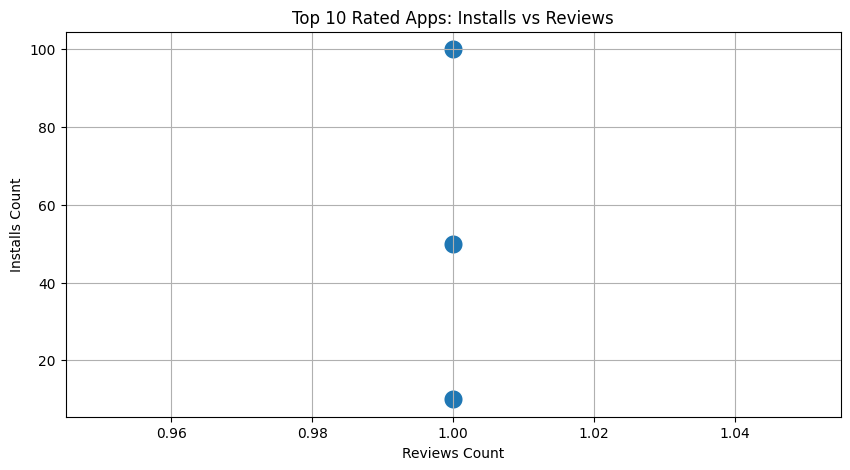

In [ ]:
# Convert Reviews properly to numeric values
top_apps = df.nlargest(10, "Rating").copy()
top_apps["Reviews"] = pd.to_numeric(top_apps["Reviews"], errors="coerce")

# Plot the scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x="Reviews", y="Installs", data=top_apps, s=200)
plt.title("Top 10 Rated Apps: Installs vs Reviews")
plt.xlabel("Reviews Count")
plt.ylabel("Installs Count")
plt.grid(True)
plt.show()

In [ ]:

# # Clean Reviews and Rating
# df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
# df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Last Updated to datetime format
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Drop missing ratings for analysis where needed
df_clean = df.dropna(subset=['Rating'])

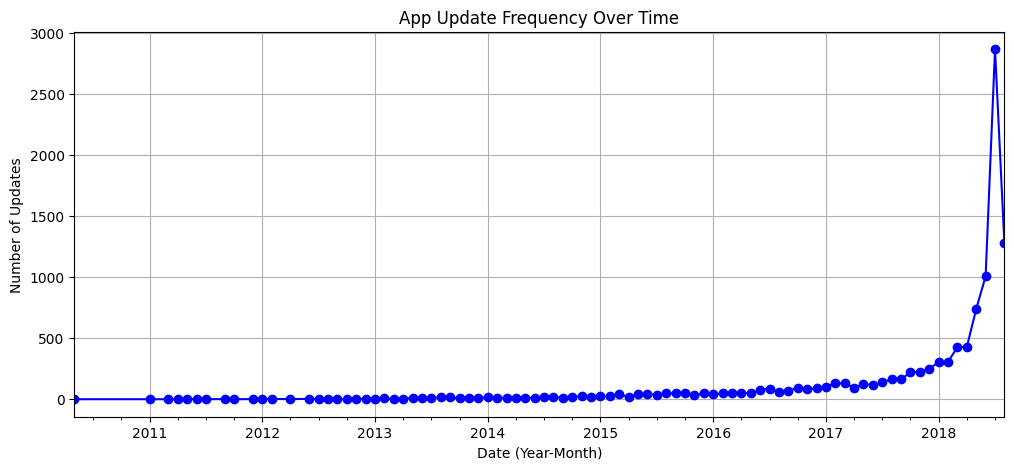

In [ ]:
# 2. Analyze the trend of app updates over time. Are there any noticeable patterns or seasonal trends?
# df["Last Updated"] = pd.to_datetime(df["Last Updated"])
# df["Year"] = df["Last Updated"].dt.year
# Extract Year and Month from Last Updated
df_clean['Update_YearMonth'] = df_clean['Last Updated'].dt.to_period('M')

# Group by time to see update frequencies
update_trend = df_clean.groupby('Update_YearMonth').size()

# Plot update trends over time
plt.figure(figsize=(12, 5))
update_trend.plot(kind='line', marker='o', color='b')
plt.title('App Update Frequency Over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Number of Updates')
plt.grid(True)
plt.show()


Average Rating by Install Bins:
                 mean  median  count
Install_Bin                         
< 1K         4.249281     4.3   2711
1K - 100K    4.074678     4.2   3179
100K - 10M   4.246240     4.3   4122
10M+         4.374396     4.4    828


/tmp/ipykernel_1129/251310235.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Install_Bin', y='Rating', palette='Set2')


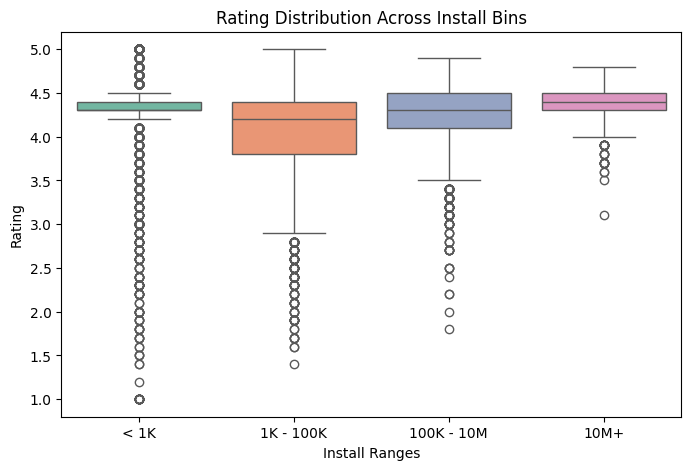

In [ ]:
# Define install bins (e.g., 0 to 1K, 1K to 100K, 100K to 10M, 10M+)
install_bins = [-1, 1000, 100000, 10000000, 1000000000]
bin_labels = ['< 1K', '1K - 100K', '100K - 10M', '10M+']

df_clean['Install_Bin'] = pd.cut(df_clean['Installs'], bins=install_bins, labels=bin_labels)

# Calculate average rating per bin
binned_rating = df_clean.groupby('Install_Bin', observed=False)['Rating'].agg(['mean', 'median', 'count'])
print("\nAverage Rating by Install Bins:")
print(binned_rating)

# Plot boxplot of ratings across install bins
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Install_Bin', y='Rating', palette='Set2')
plt.title('Rating Distribution Across Install Bins')
plt.xlabel('Install Ranges')
plt.ylabel('Rating')
plt.show()

In [ ]:
# Note: If review text dataset (user_reviews.csv) is available, merge on 'App'
# If working with app names/descriptions as a proxy for key themes:
from collections import Counter
import re

def extract_common_words(series, top_n=10):
    words = ' '.join(series.dropna().astype(str)).lower()
    clean_words = re.findall(r'\b[a-z]{3,}\b', words)
    # Exclude basic stopwords
    stopwords = set(['and', 'the', 'for', 'with', 'app', 'free', 'pro', 'mobile', 'new'])
    filtered_words = [w for w in clean_words if w not in stopwords]
    return Counter(filtered_words).most_common(top_n)

# Extract common word themes in High Rated (>= 4.5) vs Low Rated (<= 3.0) apps
high_rated_themes = extract_common_words(df_clean[df_clean['Rating'] >= 4.5]['App'])
low_rated_themes = extract_common_words(df_clean[df_clean['Rating'] <= 3.0]['App'])

print("\nCommon App Title Themes in High-Rated Apps (>= 4.5):", high_rated_themes)
print("Common App Title Themes in Low-Rated Apps (<= 3.0):", low_rated_themes)


Common App Title Themes in High-Rated Apps (>= 4.5): [('video', 74), ('photo', 61), ('live', 58), ('tracker', 57), ('news', 55), ('learn', 55), ('editor', 49), ('game', 48), ('games', 46), ('theme', 40)]
Common App Title Themes in Low-Rated Apps (<= 3.0): [('remote', 10), ('dating', 9), ('smart', 8), ('chat', 7), ('control', 5), ('advanced', 5), ('android', 5), ('universal', 4), ('anthem', 4), ('anywhere', 4)]



Top Genres by Mean Rating (Min 10 apps):
                                   mean  median  count
Genres                                                
Casual;Brain Games             4.469231     4.5     13
Adventure;Action & Adventure   4.423077     4.5     13
Simulation;Action & Adventure  4.418182     4.5     11
Word                           4.406897     4.4     29
Events                         4.395313     4.3     64
Education;Pretend Play         4.382609     4.4     23
Puzzle                         4.377857     4.4    140
Puzzle;Brain Games             4.373684     4.4     19
Education;Education            4.372000     4.4     50
Art & Design                   4.356897     4.4     58


/tmp/ipykernel_1129/79066981.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.head(10)['mean'], y=genre_ratings.head(10).index, palette='Blues_r')


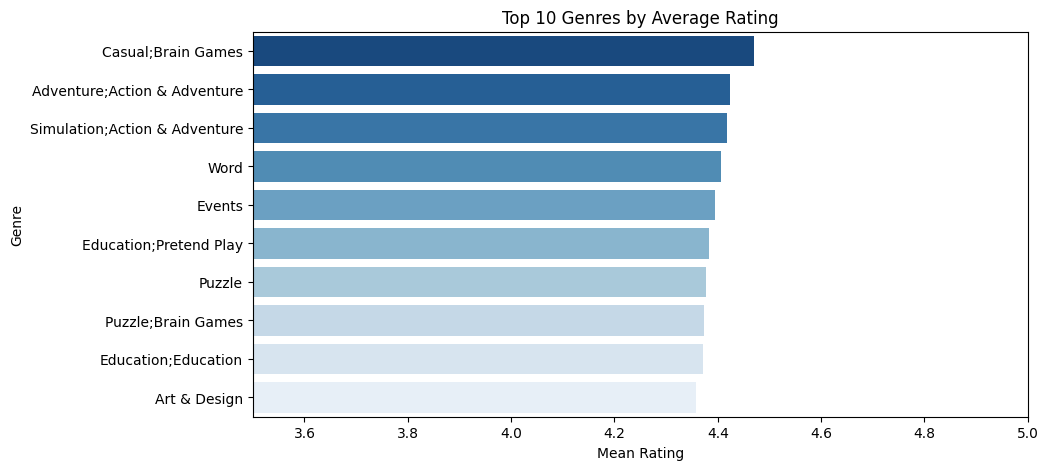

In [ ]:
# 5. What is the relationship between app genre and user ratings? Are certain genres consistently rated higher or lower?
# Calculate mean and median ratings across app genres
genre_ratings = (
    df_clean.groupby('Genres')['Rating']
    .agg(['mean', 'median', 'count'])
    .filter(items=df_clean['Genres'].value_counts()[df_clean['Genres'].value_counts() > 10].index, axis=0)
    .sort_values(by='mean', ascending=False)
)

print("\nTop Genres by Mean Rating (Min 10 apps):")
print(genre_ratings.head(10))

# Visualizing top 10 highest-rated genres
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_ratings.head(10)['mean'], y=genre_ratings.head(10).index, palette='Blues_r')
plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Mean Rating')
plt.ylabel('Genre')
plt.xlim(3.5, 5.0)
plt.show()